$$
\begin{aligned}
& \text{\textbf{Sets \& Parameters:}} \\
& N = \{0, 1, \dots, n-1\} \quad \text{(Set of all nodes, 0 is Depot)} \\
& P \subset N \times N \quad \text{(Set of precedence pairs } (p_1, p_2) \text{ where } p_1 \text{ must precede } p_2 \text{)} \\
& d_{ij} \in \mathbb{Z}^+ \quad \text{(Integer-scaled distance matrix)} \\
& K \in \mathbb{Z}^+ \quad \text{(Minimum number of nodes to visit)} \\ \\
& \text{\textbf{Decision Variables:}} \\
& z_i \in \{0, 1\} \quad \text{(1 if node } i \text{ is visited, 0 otherwise)} \\
& x_{ij} \in \{0, 1\} \quad \text{(1 if arc from } i \text{ to } j \text{ is traversed)} \\
& u_i \in \{0, 1, \dots, n-1\} \quad \text{(Sequence/step variable for node } i \text{)} \\ \\
& \text{\textbf{Objective Function:}} \\
& \min \sum_{i \in N} \sum_{\substack{j \in N \\ j \neq i}} d_{ij} x_{ij} \\ \\
& \text{\textbf{Constraints:}} \\
& \text{(1) Depot initialization:} \quad z_0 = 1, \quad u_0 = 0 \\
& \text{(2) Self-loop for unvisited nodes:} \quad x_{ii} = 1 - z_i \quad \forall i \in N \\
& \text{(3) Minimum node selection:} \quad \sum_{i \in N} z_i \ge K \\
& \text{(4) Arc-node activation linkage:} \quad x_{ij} \implies z_i = 1, \quad x_{ij} \implies z_j = 1 \quad \forall i, j \in N, i \neq j \\
& \text{(5)\ Order propagation:} \quad x_{ij} \implies u_j \ge u_i + 1 \quad \forall i \in N, \forall j \in N \setminus \{0\}, i \neq j \\
& \text{(6) Precedence presence linkage:} \quad z_{p_2} \implies z_{p_1} = 1 \quad \forall (p_1, p_2) \in P \\
& \text{(7) Precedence order linkage:} \quad (z_{p_1} \land z_{p_2}) \implies u_{p_1} < u_{p_2} \quad \forall (p_1, p_2) \in P \\
& \text{(8) Circuit validity:} \quad \text{Circuit}\left(\{ (i, j, x_{ij}) \mid i, j \in N \}\right)
\end{aligned}
$$

In [1]:
import pandas as pd
from random import randint
df = pd.read_excel("data/points.xlsx")
coords = {int(row["node"]): (row["x"], row["y"]) for i, row in df.iterrows()}

N = len(coords)
K = 20
precedence_paris = [(randint(1,99), randint(1,99)) for i in range(10)] 

print(precedence_paris)

[(63, 35), (78, 48), (64, 27), (67, 41), (87, 47), (26, 44), (17, 4), (22, 55), (63, 34), (2, 72)]


In [2]:
# coords = {
#     0: (0, 0), 1: (2, 5), 2: (8, 3), 3: (5, 9), 4: (1, 7),
#     5: (6, 4), 6: (9, 9), 7: (3, 1), 8: (7, 8), 9: (4, 4)
# }

# N = 10
# K = 6
# precedence_paris = [(1,5), (3,8)]

In [3]:
import math
distance = {}
for i in range(N):
    for j in range(N):
        if i == j:
            distance[i,j] = 0
        else:
            xi,yi = coords[i]
            xj,yj = coords[j]
            dx, dy = xi-xj , yi-yj
            distance[i,j] = math.hypot(dx,dy)

In [4]:
from ortools.sat.python import cp_model

In [5]:
model = cp_model.CpModel()

x = {}
z = {}
u = {}
arcs = []

In [6]:
for i in range(N):
    z[i] = model.NewBoolVar(f"z[{i}]")
    u[i] = model.NewIntVar(0, N-1, f"u[{i}]")
    for j in range(N):
        if i != j:
            x[i,j] = model.NewBoolVar(f"x[{i},{j}]")
            arcs.append((i,j,x[i,j]))
        elif i == j:
            # (2)self loop x[i,i] = 1-zi
            x[i,i] = z[i].Not() 
            arcs.append((i,j,x[i,i]))
            
model.AddCircuit(arcs) # (8)

# (1) depo init
model.Add(z[0] == 1)
model.Add(u[0] == 0)

#(3) minimum node selection
model.Add(sum(z[i] for i in range(N))>=K)

for i in range(N):
    for j in range(N):
        if i !=j:
            # (4) arc-node linkage
            model.Add(z[i] == 1).OnlyEnforceIf([x[i,j]])
            model.Add(z[j] == 1).OnlyEnforceIf([x[i,j]])
            # (5) Order propagation
            if j != 0:
                model.Add(u[i] + 1 <= u[j]).OnlyEnforceIf([x[i,j]])
for p1, p2 in precedence_paris:
    # (6) Precedence presence linkage (Pickup & Delivery mode)
    model.Add(z[p1] == 1).OnlyEnforceIf([z[p2]])

    # (7) precedence oreder linkage
    model.Add(u[p1]< u[p2]).OnlyEnforceIf([z[p1],z[p2]])



model.Minimize(sum(distance[i,j]*x[i,j] for i in range(N) for j in range(N) if i!=j))
    

In [7]:

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 10.0
status = solver.Solve(model)

for i in range(N):
    if solver.Value(z[i]) == 1:
        print(f"Node {i} -> Order u[{i}] = {solver.Value(u[i])}")
print("Obj value:", solver.ObjectiveValue())

Node 0 -> Order u[0] = 0
Node 1 -> Order u[1] = 7
Node 2 -> Order u[2] = 19
Node 3 -> Order u[3] = 5
Node 4 -> Order u[4] = 10
Node 5 -> Order u[5] = 3
Node 6 -> Order u[6] = 11
Node 7 -> Order u[7] = 17
Node 8 -> Order u[8] = 12
Node 9 -> Order u[9] = 16
Node 10 -> Order u[10] = 13
Node 11 -> Order u[11] = 15
Node 12 -> Order u[12] = 14
Node 13 -> Order u[13] = 1
Node 14 -> Order u[14] = 8
Node 15 -> Order u[15] = 6
Node 16 -> Order u[16] = 9
Node 17 -> Order u[17] = 2
Node 18 -> Order u[18] = 18
Node 19 -> Order u[19] = 4
Obj value: 433.4618667602044


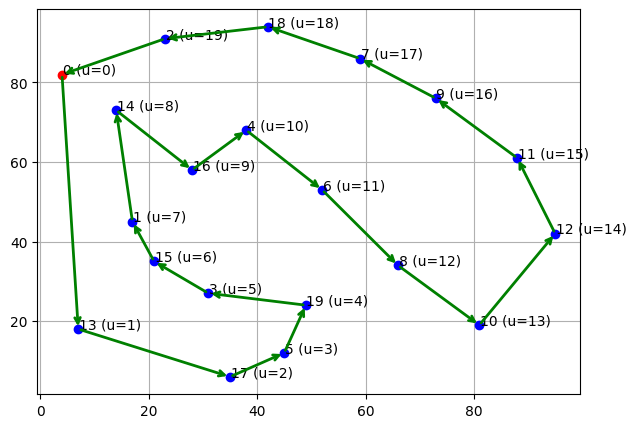

In [9]:
# Directly copy-pasted this part from AI
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))

for i in range(N):
    if solver.Value(z[i]) == 1:
        plt.plot(coords[i][0], coords[i][1], 'ro' if i == 0 else 'bo')
        plt.text(coords[i][0] + 0.1, coords[i][1] + 0.1, f"{i} (u={solver.Value(u[i])})")

for i in range(N):
    for j in range(N):
        if i != j and solver.Value(x[i, j]) == 1:
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            plt.annotate("", xy=(x2, y2), xytext=(x1, y1),
                         arrowprops=dict(arrowstyle="->", color="green", lw=2))

plt.grid(True)
plt.show()